In [2]:
import equinox as eqx
import jax.numpy as jnp
import pandas as pd

from dmm.config_options import Conf
from dmm.initialisation import get_features_filepath, process_features_and_setup_models
from dmm.training_helper_funcs import create_pypesto_problem, rmse

from common import FEATURES_OUTFILE
from dataclasses import replace
from evaluation_utils import load_model
from util import load_petab_base_files
from training_configuration import SPLITS


In [3]:
def set_param_to_zero(
        model,
        param
):
    # Find parameter deviation index
    param_idx = model.parameter_deviation_names.index(param)
    # Extract binary mask and convert to JAX array
    new_output_sparsity_binary_mask = jnp.array(model.output_sparsity_binary_mask)
    # Set value to zero and convert back to tuple format
    new_output_sparsity_binary_mask = new_output_sparsity_binary_mask.at[param_idx].set(0)
    new_output_sparsity_binary_mask = tuple(new_output_sparsity_binary_mask.tolist())
    # Replace inside model and return new model instance
    return eqx.tree_at(
        lambda model: model.output_sparsity_binary_mask,
        model,
        new_output_sparsity_binary_mask,
    )

In [12]:
from tqdm import tqdm

conf = Conf(
    model = "EGFR_MAPK__logobs",  # base model
    data = "dream_cytof",
    context = "multimodal",
    features = "best_RFE_10_permute",
    n_hidden = 2,
    depth = 0,
    l1reg_inflater_output = 1e-2,
    inflater_output_reg_epoch=200,
    inflater_bound=3,
    l2reg_inflater_output = 0,
    n_epoch=500,
)

# parameters_interest = [
#     "EGFR_p_Y1173_EGF_0_kw",
#     "ERBB2_p_Y1248_EGFR__Y1173_p_kw",
#     "ERBB2_p_Y1248_ERBB2_kw"
# ]
parameters_interest = None


# Load petab_base_files (once only)
petab_base_files = load_petab_base_files(conf)


res = []
for samples in sorted(SPLITS):
    print(f"Now analysing {samples}...")
    subconf = replace(conf, samples=samples)
    # Get filepaths for features and feature transformation pipeline
    features_filepath = get_features_filepath(subconf, FEATURES_OUTFILE)

    for job in range(10):
        subconf = replace(subconf, job=job)
        (
            _,
            problem,
            pypesto_subproblems,
            features,
        ) = process_features_and_setup_models(
            conf=conf,
            features_filepath=features_filepath,
            petab_base_files=petab_base_files,
            dataset="train+val",
        )

        model = load_model(subconf, pypesto_subproblems["train"])
        print(f"Model loaded successfully for job {job}.")

        # Get list of parameter deviation names to perturb
        if parameters_interest is None:
            parameters_interest = model.parameter_deviation_names

        pypesto_problems = {
            dataset: create_pypesto_problem(pypesto_subproblems[dataset])
            for dataset in ["train", "val"]
        }

        for param in tqdm(parameters_interest):
            new_model = set_param_to_zero(
                model, param
            )
            for dataset in ["train", "val"]:
                rmse_pristine = rmse(pypesto_problems[dataset], model, features[dataset].values)
                rmse_zeroed = rmse(pypesto_problems[dataset], new_model, features[dataset].values)
                res.append(
                    {
                        "samples": samples,
                        "job": job,
                        "param": param,
                        "dataset": dataset,
                        "rmse_pristine": rmse_pristine,
                        "rmse_zeroed": rmse_zeroed,
                        "rmse_diff": rmse_zeroed - rmse_pristine,
                    }
                )

results = pd.DataFrame(res)

Now analysing BT20
Model loaded successfully for job 0.


100%|██████████| 34/34 [00:41<00:00,  1.22s/it]


Model loaded successfully for job 1.


100%|██████████| 34/34 [00:40<00:00,  1.20s/it]


Model loaded successfully for job 2.


...

100%|██████████| 34/34 [00:42<00:00,  1.25s/it]


Model loaded successfully for job 8.


100%|██████████| 34/34 [00:42<00:00,  1.25s/it]


Model loaded successfully for job 9.


100%|██████████| 34/34 [00:43<00:00,  1.28s/it]


In [14]:
results

,samples,job,param,dataset,rmse_pristine,rmse_zeroed,rmse_diff
0,BT20,0,ERBB2_dp_Y1248_kcat,train,0.432223,0.434486,0.002262
1,BT20,0,ERBB2_dp_Y1248_kcat,val,0.534606,0.526651,-0.007955
2,BT20,0,EGFR_deg_kdeg,train,0.432223,0.432223,0.000000
3,BT20,0,EGFR_deg_kdeg,val,0.534606,0.534606,0.000000
4,BT20,0,EGFR_dp_Y1173_kcat,train,0.432223,0.432223,0.000000
...,...,...,...,...,...,...,...
3395,UACC3199,9,RPS6KA1_p_S380_ERK__Y204_p_kw,val,0.552611,0.548585,-0.004026
3396,UACC3199,9,RPS6KA1_p_S380_EGFR__Y1173_p_kw,train,0.437025,0.444123,0.007098
3397,UACC3199,9,RPS6KA1_p_S380_EGFR__Y1173_p_kw,val,0.552611,0.539339,-0.013272
3398,UACC3199,9,RPS6KA1_p_S380_ERBB2__Y1248_p_kw,train,0.437025,0.439388,0.002363


In [16]:
results.to_csv("sensitivity_analysis_multimodal_base.csv", index=False)

In [43]:
results_df = pd.read_csv("sensitivity_analysis_multimodal_base.csv")
val_results = results_df[results_df.dataset == "val"]

val_results = pd.pivot_table(
    val_results,
    values="rmse_diff",
    columns="param",
    index="samples",
    aggfunc="mean"
)

In [44]:
val_results

param,EGFR_deg_bact,EGFR_deg_kdeg,EGFR_dp_Y1173_kcat,EGFR_endo_EGFR__Y1173_p_kw,EGFR_endo_EGFR_kw,EGFR_endo_EGF_0_kw,EGFR_endo_ERBB2_kw,EGFR_endo_ERK__Y204_p_kw,EGFR_endo_bact,EGFR_p_Y1173_EGF_0_kw,...,MEK_dp_S222_kcat,MEK_p_S222_EGFR__Y1173_p_kw,MEK_p_S222_ERBB2__Y1248_p_kw,MEK_p_S222_ERK__Y204_p_kw,MEK_p_S222_bact,RPS6KA1_dp_S380_kcat,RPS6KA1_p_S380_EGFR__Y1173_p_kw,RPS6KA1_p_S380_ERBB2__Y1248_p_kw,RPS6KA1_p_S380_ERK__Y204_p_kw,RPS6KA1_p_S380_bact
samples,,,,,,,,,,,,,,,,,,,,,
BT20,0.0,0.000000e+00,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.016417,...,0.0,0.004008,0.065430,0.041768,0.000913,0.0,0.000544,-0.000032,0.023812,-0.000086
EVSAT,0.0,0.000000e+00,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.449049,...,0.0,0.072630,-0.000383,0.000000,0.003357,0.0,0.032853,0.000000,0.034376,-0.005414
HCC1500,0.0,0.000000e+00,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.642356,...,0.0,0.013790,0.000157,0.021064,0.008595,0.0,0.000283,-0.032364,0.128340,-0.000216
MCF7,0.0,0.000000e+00,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.099637,...,0.0,0.007620,0.001583,0.011095,-0.002571,0.0,-0.002250,0.007197,0.009987,-0.001884
UACC3199,0.0,-9.029521e-07,0.0,0.0,0.014318,0.0,0.000038,0.0,0.011805,0.023909,...,0.0,0.000813,0.059729,-0.005283,-0.001345,0.0,-0.000539,-0.000011,0.064118,-0.001926


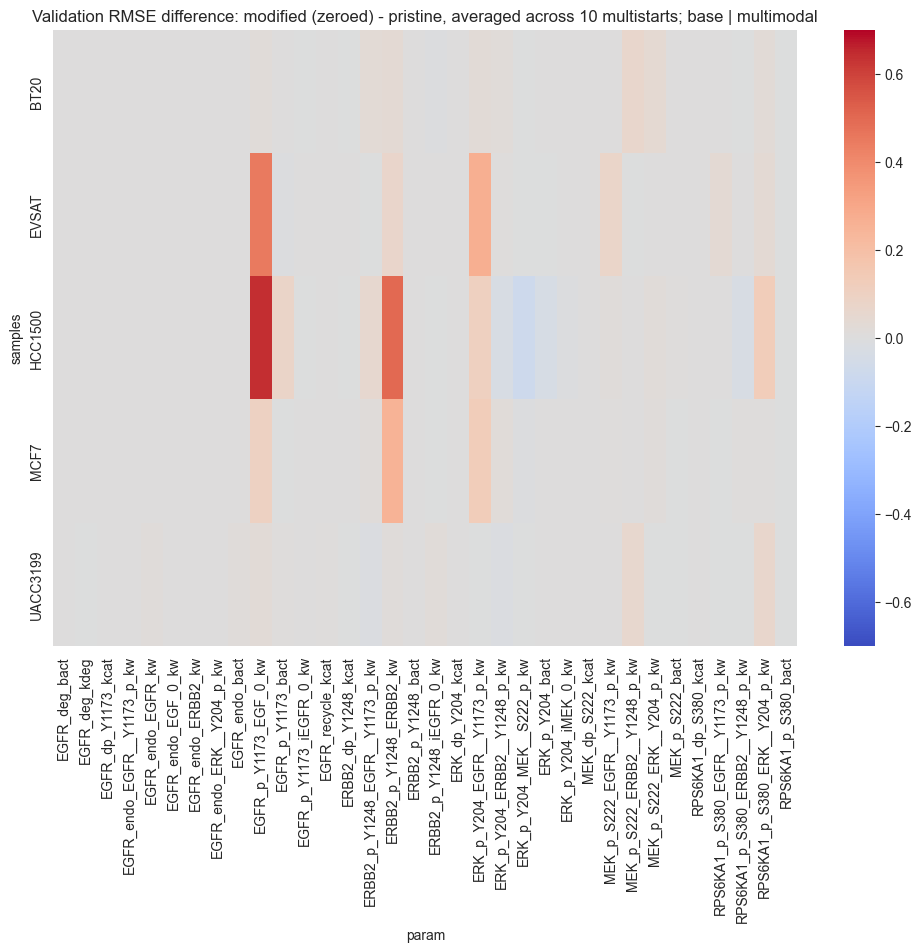

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(val_results, cmap="coolwarm", vmin=-0.7, vmax=0.7, xticklabels=val_results.columns)
plt.title("Validation RMSE difference: modified (zeroed) - pristine, averaged across 10 multistarts; base | multimodal");
plt.savefig("sensitivity_analysis_multimodal_base.png")